# Benchmark: Pauli Propagation vs Other Executors

This notebook compares execution speed of `PauliPropagationExecutor` against `PennyLaneExecutor`, `QulacsExecutor`, and `QiskitExecutor` for computing expectation values of quantum circuits.

Pauli propagation works in the Heisenberg picture and is most efficient when the observable is sparse (few Pauli terms) and the circuit doesn't generate too many new terms during propagation.

In [1]:
import numpy as np
import time
from qc_executor import QuantumCircuit, QuantumOperator

# Import all available executors
executors = {}

from qc_executor.pauli_propagation import PauliPropagationExecutor

executors["PauliPropagation"] = PauliPropagationExecutor(seed=0)

try:
    from qc_executor.pennylane.pennylane_executor import PennyLaneExecutor

    executors["PennyLane"] = PennyLaneExecutor(seed=0)
except ImportError as e:
    print(f"PennyLane not available: {e}")

try:
    from qc_executor.qulacs.qulacs_executor import QulacsExecutor

    executors["Qulacs"] = QulacsExecutor(seed=0)
except ImportError as e:
    print(f"Qulacs not available: {e}")

try:
    from qc_executor.qiskit.qiskit_executor import QiskitExecutor

    executors["Qiskit"] = QiskitExecutor(seed=0)
except ImportError as e:
    print(f"Qiskit executor not available: {e}")

print(f"Available executors: {list(executors.keys())}")

c:\Users\mow\Documents\Dev\Executor\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Available executors: ['PauliPropagation', 'PennyLane', 'Qulacs', 'Qiskit']


## Helper functions

In [2]:
def build_clifford_circuit(n_qubits, depth=10):
    """Build a deep Clifford circuit with a single rotation at the end.

    This is favorable for Pauli propagation: Clifford gates map Pauli
    strings to Pauli strings (no term splitting), so the observable
    stays compact throughout propagation.
    """
    qc = QuantumCircuit(n_qubits)
    for _ in range(depth):
        for q in range(n_qubits):
            qc.h(q)
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
    # Only 1 rotation gate at the end
    qc.rz(0, 0.1)
    return qc


def build_rotation_circuit(n_qubits, depth=5):
    """Build a circuit with many rotation gates.

    This is harder for Pauli propagation: each non-commuting rotation
    can double the number of Pauli terms in the observable.
    """
    qc = QuantumCircuit(n_qubits)
    for _ in range(depth):
        for q in range(n_qubits):
            qc.rx(q, 0.3 * (q + 1))
            qc.rz(q, 0.2 * (q + 1))
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
    return qc


def time_executor(executor, circuit, observable, n_runs=5):
    """Time an executor's expectation_value call. Returns (mean_time, result)."""
    # Warmup
    try:
        transpiled_circuit = executor.transpile_circuit(circuit)
        transpiled_observable = executor.transpile_operator(observable)
        result = executor.expectation_value(transpiled_circuit, transpiled_observable)
    except Exception as e:
        return None, str(e)

    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        result = executor.expectation_value(transpiled_circuit, transpiled_observable)
        elapsed = time.perf_counter() - start
        times.append(elapsed)

    return np.mean(times), result


def run_benchmark(circuit, observable, label, n_runs=5):
    """Run all executors on a given circuit+observable and print results."""
    print(f'\n{"=" * 60}')
    print(f"{label}")
    print(f'{"=" * 60}')

    results = {}
    for name, executor in executors.items():
        t, val = time_executor(executor, circuit, observable, n_runs=n_runs)
        if t is not None:
            results[name] = (t, val)
            print(f"  {name:20s}  {t*1000:8.2f} ms   result = {val:.10f}")
        else:
            print(f"  {name:20s}  FAILED: {val}")

    # Show speedup relative to fastest statevector method
    sv_times = {k: v[0] for k, v in results.items() if k != "PauliPropagation"}
    if sv_times and "PauliPropagation" in results:
        pp_time = results["PauliPropagation"][0]
        fastest_sv = min(sv_times.values())
        fastest_name = min(sv_times, key=sv_times.get)
        speedup = fastest_sv / pp_time
        if speedup > 1:
            print(f"  -> PauliPropagation is {speedup:.1f}x faster than {fastest_name}")
        else:
            print(f"  -> PauliPropagation is {1/speedup:.1f}x slower than {fastest_name}")

    return results

## Benchmark 1: Clifford circuit + sparse observable

This is the best-case scenario for Pauli propagation. The circuit is mostly Clifford gates (H, CNOT) which don't increase the number of Pauli terms, and the observable has only 1 term.

In [3]:
for n_qubits in [4, 8, 12, 16, 20]:
    circuit = build_clifford_circuit(n_qubits, depth=10)
    n_gates = len(circuit._qiskit_circuit.data)

    # Single Pauli term observable
    obs_str = "Z" + "I" * (n_qubits - 1)
    observable = QuantumOperator([obs_str], [1.0])

    run_benchmark(
        circuit,
        observable,
        f"Clifford circuit: {n_qubits} qubits, {n_gates} gates, 1 Pauli term",
        n_runs=3,
    )


Clifford circuit: 4 qubits, 71 gates, 1 Pauli term
  PauliPropagation          0.42 ms   result = 1.0000000000
  PennyLane                 7.19 ms   result = 1.0000000000
  Qulacs                   15.61 ms   result = 1.0000000000
  Qiskit                   11.44 ms   result = 1.0000000000
  -> PauliPropagation is 17.1x faster than PennyLane

Clifford circuit: 8 qubits, 151 gates, 1 Pauli term
  PauliPropagation          1.41 ms   result = 1.0000000000
  PennyLane                16.54 ms   result = 1.0000000000
  Qulacs                   21.69 ms   result = 1.0000000000
  Qiskit                   22.04 ms   result = 1.0000000000
  -> PauliPropagation is 11.8x faster than PennyLane

Clifford circuit: 12 qubits, 231 gates, 1 Pauli term
  PauliPropagation          1.22 ms   result = 1.0000000000
  PennyLane                33.88 ms   result = 1.0000000000
  Qulacs                   43.74 ms   result = 1.0000000000
  Qiskit                   29.61 ms   result = 1.0000000000
  -> PauliPropa

## Benchmark 2: Clifford circuit + multi-term observable

Same Clifford-heavy circuit but with a 3-term observable. Pauli propagation handles each term independently.

In [4]:
for n_qubits in [4, 8, 12, 16, 20]:
    circuit = build_clifford_circuit(n_qubits, depth=10)
    n_gates = len(circuit._qiskit_circuit.data)

    # 3-term observable
    paulis = [
        "Z" + "I" * (n_qubits - 1),
        "I" * (n_qubits - 1) + "Z",
        "ZZ" + "I" * (n_qubits - 2),
    ]
    observable = QuantumOperator(paulis, [0.5, 0.3, 0.2])

    run_benchmark(
        circuit,
        observable,
        f"Clifford circuit: {n_qubits} qubits, {n_gates} gates, 3 Pauli terms",
        n_runs=3,
    )


Clifford circuit: 4 qubits, 71 gates, 3 Pauli terms
  PauliPropagation          0.91 ms   result = 1.0000000000
  PennyLane                14.33 ms   result = 3.0000000000
  Qulacs                   20.28 ms   result = 1.0000000000
  Qiskit                   12.63 ms   result = 1.0000000000
  -> PauliPropagation is 13.9x faster than Qiskit

Clifford circuit: 8 qubits, 151 gates, 3 Pauli terms
  PauliPropagation          2.57 ms   result = 1.0000000000
  PennyLane                20.88 ms   result = 3.0000000000
  Qulacs                   19.42 ms   result = 1.0000000000
  Qiskit                   22.86 ms   result = 1.0000000000
  -> PauliPropagation is 7.6x faster than Qulacs

Clifford circuit: 12 qubits, 231 gates, 3 Pauli terms
  PauliPropagation          1.53 ms   result = 1.0000000000
  PennyLane                37.05 ms   result = 3.0000000000
  Qulacs                   37.30 ms   result = 1.0000000000
  Qiskit                   35.23 ms   result = 1.0000000000
  -> PauliPropagati

## Benchmark 3: Rotation-heavy circuits (increasing depth)

Circuits with many non-commuting rotations make the propagated observable grow with depth: each anticommuting rotation can double the number of Pauli terms. This benchmark sweeps the circuit depth at a fixed qubit count to show where *exact* Pauli propagation loses its advantage over statevector methods (Benchmark 4 shows how truncation recovers it).

In [5]:
n_qubits = 12
for depth in [2, 4, 6, 8]:
    circuit = build_rotation_circuit(n_qubits, depth=depth)
    n_gates = len(circuit._qiskit_circuit.data)

    obs_str = "Z" + "I" * (n_qubits - 1)
    observable = QuantumOperator([obs_str], [1.0])

    run_benchmark(
        circuit,
        observable,
        f"Rotation circuit: {n_qubits} qubits, {n_gates} gates, depth={depth}",
        n_runs=3,
    )


Rotation circuit: 12 qubits, 70 gates, depth=2
  PauliPropagation          0.56 ms   result = 0.8938477957
  PennyLane                29.76 ms   result = 0.8938477957
  Qulacs                  451.45 ms   result = 0.8938477957
  Qiskit                   17.48 ms   result = 0.0028786949
  -> PauliPropagation is 31.4x faster than Qiskit

Rotation circuit: 12 qubits, 140 gates, depth=4
  PauliPropagation          4.59 ms   result = 0.6554066225
  PennyLane                19.89 ms   result = 0.6554066225
  Qulacs                  885.18 ms   result = 0.6554066225
  Qiskit                   28.21 ms   result = -0.0027181104
  -> PauliPropagation is 4.3x faster than PennyLane

Rotation circuit: 12 qubits, 210 gates, depth=6
  PauliPropagation         10.07 ms   result = 0.4619496322
  PennyLane                34.42 ms   result = 0.4619496322
  Qulacs                 1328.79 ms   result = 0.4619496322
  Qiskit                   31.27 ms   result = 0.0069161158
  -> PauliPropagation is 3.1x f

## Benchmark 4: Pauli propagation with truncation

Truncation keeps only significant Pauli terms, trading exact accuracy for speed. This makes rotation-heavy circuits tractable at the cost of a small approximation error.

In [6]:
n_qubits = 12
circuit = build_rotation_circuit(n_qubits, depth=8)
n_gates = len(circuit._qiskit_circuit.data)
obs_str = "Z" + "I" * (n_qubits - 1)
observable = QuantumOperator([obs_str], [1.0])

print(f"Circuit: {n_qubits} qubits, {n_gates} gates, depth=8")
print()

# Exact (no truncation)
exec_exact = PauliPropagationExecutor()
t_exact, val_exact = time_executor(exec_exact, circuit, observable, n_runs=3)
if t_exact is not None:
    print(f"  Exact:                {t_exact*1000:8.2f} ms   result = {val_exact:.10f}")
else:
    print(f"  Exact:                FAILED (too many terms)")
    val_exact = None

# With various truncation thresholds
for threshold in [1e-2, 1e-4, 1e-6, 1e-8]:
    exec_trunc = PauliPropagationExecutor(truncate_threshold=threshold)
    t, val = time_executor(exec_trunc, circuit, observable, n_runs=3)
    if t is not None:
        error = abs(val - val_exact) if val_exact is not None else float("nan")
        stats = exec_trunc.get_truncation_stats()
        n_remaining = stats.terms_remaining if stats else "?"
        print(
            f"  threshold={threshold:.0e}:  {t*1000:8.2f} ms   result = {val:.10f}   error = {error:.2e}   terms = {n_remaining}"
        )
    else:
        print(f"  threshold={threshold:.0e}:  FAILED")

Circuit: 12 qubits, 280 gates, depth=8

  Exact:                  227.06 ms   result = 0.4491998846
  threshold=1e-02:     12.50 ms   result = 0.5320004006   error = 8.28e-02   terms = 361
  threshold=1e-04:     77.87 ms   result = 0.4493800877   error = 1.80e-04   terms = 20270
  threshold=1e-06:    202.39 ms   result = 0.4491981189   error = 1.77e-06   terms = 59992
  threshold=1e-08:    214.86 ms   result = 0.4491998859   error = 1.36e-09   terms = 65235


## Benchmark 5: Scaling with qubit count (Clifford circuit)

Statevector-based methods scale as O(2^n). Pauli propagation with sparse observables on Clifford circuits stays polynomial.

In [7]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)  # suppress large-qubit warnings

qubit_counts = [4, 8, 12, 16, 20, 24]
timing_data = {name: [] for name in executors}

for n_qubits in qubit_counts:
    circuit = build_clifford_circuit(n_qubits, depth=10)
    obs_str = "Z" + "I" * (n_qubits - 1)
    observable = QuantumOperator([obs_str], [1.0])

    print(f"\n{n_qubits} qubits:")
    for name, executor in executors.items():
        # Skip statevector methods for large qubit counts
        if name != "PauliPropagation" and n_qubits > 20:
            timing_data[name].append(None)
            print(f"  {name:20s}  skipped (too large for statevector)")
            continue

        t, val = time_executor(executor, circuit, observable, n_runs=3)
        timing_data[name].append(t)
        if t is not None:
            print(f"  {name:20s}  {t*1000:8.2f} ms")
        else:
            print(f"  {name:20s}  FAILED")


4 qubits:
  PauliPropagation          0.35 ms
  PennyLane                 6.57 ms
  Qulacs                   22.18 ms
  Qiskit                   11.49 ms

8 qubits:
  PauliPropagation          1.64 ms
  PennyLane                21.90 ms
  Qulacs                   17.80 ms
  Qiskit                   25.50 ms

12 qubits:
  PauliPropagation          1.90 ms
  PennyLane                33.03 ms
  Qulacs                   40.95 ms
  Qiskit                   32.07 ms

16 qubits:
  PauliPropagation          1.02 ms
  PennyLane               353.02 ms
  Qulacs                   29.72 ms
  Qiskit                  588.38 ms

20 qubits:
  PauliPropagation          1.46 ms
  PennyLane              5003.35 ms
  Qulacs                  248.34 ms
  Qiskit                 8101.72 ms

24 qubits:
  PauliPropagation          1.60 ms
  PennyLane             skipped (too large for statevector)
  Qulacs                skipped (too large for statevector)
  Qiskit                skipped (too large for stateve

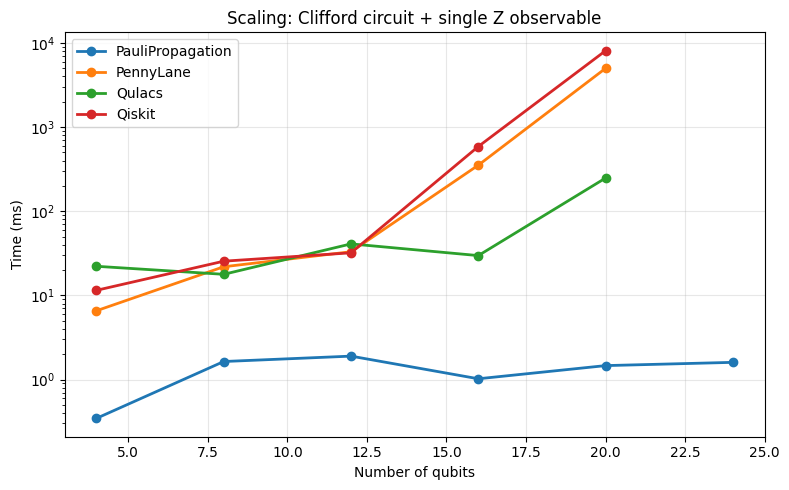

In [8]:
# Plot scaling
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, times in timing_data.items():
        valid = [(q, t) for q, t in zip(qubit_counts, times) if t is not None]
        if valid:
            qs, ts = zip(*valid)
            ax.plot(qs, [t * 1000 for t in ts], "o-", label=name, linewidth=2)

    ax.set_xlabel("Number of qubits")
    ax.set_ylabel("Time (ms)")
    ax.set_title("Scaling: Clifford circuit + single Z observable")
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed, skipping plot")

## Summary

| Scenario | Pauli Propagation | Statevector methods |
|---|---|---|
| Clifford circuit + sparse observable | Very fast (polynomial) | O(2^n) |
| Clifford circuit + dense observable | Fast (linear in # terms) | O(2^n) |
| Rotation-heavy circuit | Exponential term growth | O(2^n) |
| Rotation-heavy + truncation | Controllable tradeoff | O(2^n) |